# Exercice 3.4 — Dask pour datasets volumineux

Objectif du notebook:
- charger les 12 fichiers avec `dask.dataframe.read_parquet("data/raw/*.parquet")`,
- reproduire les calculs de l'exercice 3.2 (`groupby` + `pivoting`),
- comparer Pandas et Dask sur le temps d'exécution,
- observer le pic mémoire côté Dask via le dashboard,
- vérifier l'égalité des résultats après `.compute()`.

Ce notebook sépare volontairement:
1. un benchmark **équitable** sur un sous-ensemble de fichiers,
2. un benchmark **Dask full 12 mois**,
3. un benchmark **Pandas full** désactivé par défaut pour éviter un OOM.

In [1]:
from __future__ import annotations

import json
import sys
import tracemalloc
from pathlib import Path
from time import perf_counter

import dask.dataframe as dd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dask.distributed import Client
from IPython.display import display
from pandas.testing import assert_frame_equal

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from features.encoding import (
    build_activity_dashboard,
    build_activity_dashboard_dask,
    load_raw_with_dask,
    pivot_activity_table,
)

sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 40
pd.options.display.float_format = "{:,.4f}".format

## Paramètres

- `SUBSET_FILE_COUNT` sert au benchmark équitable Pandas vs Dask.
- `RUN_FULL_DASK` exécute Dask sur les 12 mois.
- `RUN_FULL_PANDAS` reste `False` par défaut pour éviter de tuer le kernel.

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PATTERN = str(DATA_DIR / "yellow_tripdata_2023-*.parquet")
PARQUET_FILES = sorted(DATA_DIR.glob("yellow_tripdata_2023-*.parquet"))

COLUMNS = [
    "PULocationID",
    "tpep_pickup_datetime",
    "total_amount",
    "tip_amount",
    "fare_amount",
]

SUBSET_FILE_COUNT = 3
RUN_FULL_DASK = True
RUN_FULL_PANDAS = False
START_DASK_CLIENT = True

subset_files = PARQUET_FILES[:SUBSET_FILE_COUNT]
print("Project root:", PROJECT_ROOT)
print("Files found:", len(PARQUET_FILES))
print("Subset files:", [path.name for path in subset_files])

Project root: /Users/apple/Projects/tp_taxi
Files found: 12
Subset files: ['yellow_tripdata_2023-01.parquet', 'yellow_tripdata_2023-02.parquet', 'yellow_tripdata_2023-03.parquet']


In [3]:
client = None
if START_DASK_CLIENT:
    client = Client(processes=True)
    print(client)
    print("Dask dashboard:", client.dashboard_link)

<Client: 'tcp://127.0.0.1:54149' processes=4 threads=8, memory=8.00 GiB>
Dask dashboard: http://127.0.0.1:8787/status


## Helpers

On recrée les colonnes nécessaires à l'exercice 3.2, notamment `tip_pct`, avant de lancer les agrégations.

In [4]:
def prepare_pandas_frame(paths: list[Path]) -> pd.DataFrame:
    frames = []
    for path in paths:
        df = pd.read_parquet(path, columns=COLUMNS)
        df = df.loc[df["fare_amount"] > 0].copy()
        df["tip_pct"] = df["tip_amount"] / df["fare_amount"]
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def prepare_dask_frame(pattern_or_paths: str | list[Path]):
    if isinstance(pattern_or_paths, list):
        ddf = dd.read_parquet([str(path) for path in pattern_or_paths], columns=COLUMNS)
    else:
        ddf = load_raw_with_dask(pattern_or_paths, columns=COLUMNS)
    ddf = ddf[ddf["fare_amount"] > 0]
    ddf = ddf.assign(tip_pct=ddf["tip_amount"] / ddf["fare_amount"])
    return ddf


def benchmark(label: str, func, *args, **kwargs):
    tracemalloc.start()
    started_at = perf_counter()
    result = func(*args, **kwargs)
    elapsed_s = perf_counter() - started_at
    _, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return {
        "label": label,
        "elapsed_s": elapsed_s,
        "peak_python_mb": peak_bytes / (1024 ** 2),
        "result": result,
    }


def compute_activity_and_pivot_pandas(paths: list[Path]):
    df = prepare_pandas_frame(paths)
    activity = build_activity_dashboard(df).sort_index()
    pivot = pivot_activity_table(activity).sort_index()
    return activity, pivot


def compute_activity_and_pivot_dask(pattern_or_paths: str | list[Path]):
    ddf = prepare_dask_frame(pattern_or_paths)
    activity = build_activity_dashboard_dask(ddf).compute().sort_index()
    pivot = pivot_activity_table(activity).sort_index()
    return activity, pivot


def summarize_activity(activity: pd.DataFrame) -> dict:
    return {
        "rows": int(len(activity)),
        "trip_count_sum": float(activity["trip_count"].sum()),
        "revenue_total_sum": float(activity["revenue_total"].sum()),
        "tip_pct_mean_mean": float(activity["tip_pct_mean"].mean()),
    }

## Benchmark équitable Pandas vs Dask sur le même sous-ensemble

C'est la comparaison la plus rigoureuse pour le rapport: même input, mêmes calculs, mêmes résultats attendus.

In [5]:
pandas_bench = benchmark("pandas_subset", compute_activity_and_pivot_pandas, subset_files)
dask_bench = benchmark("dask_subset", compute_activity_and_pivot_dask, subset_files)

pandas_activity, pandas_pivot = pandas_bench["result"]
dask_activity, dask_pivot = dask_bench["result"]

assert_frame_equal(pandas_activity, dask_activity)
assert_frame_equal(pandas_pivot, dask_pivot)

print("Equality check activity: OK")
print("Equality check pivot: OK")
print(json.dumps(summarize_activity(pandas_activity), indent=2))

Equality check activity: OK
Equality check pivot: OK
{
  "rows": 31017,
  "trip_count_sum": 9301614.0,
  "revenue_total_sum": 257802624.85999998,
  "tip_pct_mean_mean": 0.19658340629901475
}


In [6]:
subset_benchmark_df = pd.DataFrame([
    {k: v for k, v in pandas_bench.items() if k != "result"},
    {k: v for k, v in dask_bench.items() if k != "result"},
])
subset_benchmark_df

,label,elapsed_s,peak_python_mb
0,pandas_subset,4.1558,"1,419.8131"
1,dask_subset,2.2003,4.5908


/var/folders/yz/bcjnqgg13kvd9spkss842b280000gn/T/ipykernel_9113/1589931908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset_benchmark_df, x="label", y="elapsed_s", ax=axes[0], palette="Blues_d")
/var/folders/yz/bcjnqgg13kvd9spkss842b280000gn/T/ipykernel_9113/1589931908.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset_benchmark_df, x="label", y="peak_python_mb", ax=axes[1], palette="Greens_d")


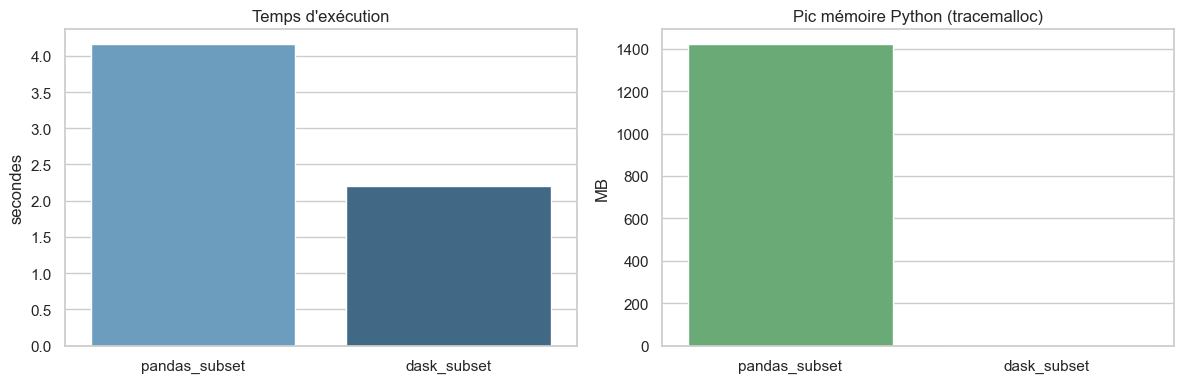

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=subset_benchmark_df, x="label", y="elapsed_s", ax=axes[0], palette="Blues_d")
axes[0].set_title("Temps d'exécution")
axes[0].set_ylabel("secondes")
axes[0].set_xlabel("")

sns.barplot(data=subset_benchmark_df, x="label", y="peak_python_mb", ax=axes[1], palette="Greens_d")
axes[1].set_title("Pic mémoire Python (tracemalloc)")
axes[1].set_ylabel("MB")
axes[1].set_xlabel("")

plt.tight_layout()

## Résultats intermédiaires

Tu peux afficher ici les DataFrames finaux pour vérifier visuellement la cohérence des agrégations.

In [8]:
display(pandas_activity.head())
display(pandas_pivot.head())

trip_count  revenue_total  tip_pct_mean
PULocationID hour weekday                                         
1            0    1                 1       141.0000        0.0000
                  2                 1       252.0500        0.0000
                  5                 1        59.3800        0.2640
             1    1                 2        26.5000        0.0000
                  3                 1        11.0000        0.0000

tip_pct_mean                                                   \
hour                   0      1      2      3      4      5      6      7    
PULocationID                                                                 
1                  0.0880 0.0000 0.0450 0.1192 0.1375 0.2427 0.0842 3.0296   
2                     NaN    NaN    NaN    NaN    NaN    NaN    NaN 0.1429   
3                  0.0000    NaN    NaN    NaN 0.0000    NaN 0.0000 0.0000   
4                  0.2008 0.2215 0.2124 0.2221 0.1752 0.1432 0.1662 0.1706   
5                     NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   

                                                                              \
hour             8      9      10     11     12      13     14     15     16   
PULocationID                                                                   
1            0.1590 0.1820 0.2538 0.1272 1.0595 13.8524 0.3547 0.4256 0.5597   
2               NaN    NaN 0.2512 0.2301    NaN     NaN    NaN    NaN    NaN   
3            0.0013 0.0012 0.0000 0.0072 0.0352  0.0039 0.0000 0.0000 0.0000   
4            0.1731 0.1807 0.1927 0.1530 0.1531  0.1484 0.1632 0.2038 0.1839   
5            0.0000 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000   

                                   ... trip_count                         \
hour             17     18     19  ...         4      5       6       7    
PULocationID                       ...                                     
1            0.1124 0.6006 2.1666  ...     3.8571 5.5714  5.4286  5.5714   
2            0.0000    NaN 0.0000  ...        NaN    NaN     NaN  1.0000   
3            0.0514 0.0000 0.0000  ...     1.0000    NaN  1.4000  4.2000   
4            0.1727 0.2047 0.1873  ...    32.4286 5.7143 16.5714 31.7143   
5            0.0000 0.0000 0.0000  ...        NaN    NaN     NaN     NaN   

                                                                              \
hour              8       9       10      11      12      13      14      15   
PULocationID                                                                   
1             5.7143  4.5714  5.7143  5.7143  9.5714 13.5714 16.1429 21.7143   
2                NaN     NaN  1.0000  1.0000     NaN     NaN     NaN     NaN   
3             2.2000  1.8333  2.0000  2.8333  1.8333  2.5000  1.3333  1.6000   
4            55.5714 46.0000 33.8571 31.8571 39.2857 38.7143 33.8571 37.8571   
5             2.3333  2.0000  3.0000  2.2500  2.4000  2.0000  1.3333  2.0000   

                                                                               
hour              16      17      18      19      20      21      22       23  
PULocationID                                                                   
1            18.1429 17.5714 13.7143  6.0000  4.1667  2.4000  1.8000   1.5000  
2                NaN  1.0000     NaN  1.0000     NaN     NaN     NaN      NaN  
3             1.0000  1.6000  1.0000  1.0000  1.4000  2.0000  1.0000      NaN  
4            34.2857 41.7143 57.8571 55.0000 47.7143 60.4286 86.8571 127.4286  
5             2.1429  1.3333  1.8333  2.1667  2.4286  1.5714  1.5000   1.0000  

[5 rows x 48 columns]

## Dask sur les 12 mois

Cette cellule répond directement à l'exigence 61 du sujet (`read_parquet("data/raw/*.parquet")`).

Pour le pic mémoire réel côté Dask, observe le dashboard affiché dans `client.dashboard_link`, généralement `http://localhost:8787`.

In [9]:
if RUN_FULL_DASK:
    full_dask_bench = benchmark("dask_full_12_months", compute_activity_and_pivot_dask, DATA_PATTERN)
    full_dask_activity, full_dask_pivot = full_dask_bench["result"]
    display(pd.DataFrame([{k: v for k, v in full_dask_bench.items() if k != "result"}]))
    print(json.dumps(summarize_activity(full_dask_activity), indent=2))
else:
    print("RUN_FULL_DASK=False -> cellule non exécutée.")

,label,elapsed_s,peak_python_mb
0,dask_full_12_months,13.2240,5.2951


{
  "rows": 38092,
  "trip_count_sum": 37915723.0,
  "revenue_total_sum": 1100101188.43,
  "tip_pct_mean_mean": 0.31960927948458184
}


## Pandas sur les 12 mois

Désactivé par défaut. Sur une machine limitée, cette cellule peut provoquer un OOM.

In [10]:
if RUN_FULL_PANDAS:
    full_pandas_bench = benchmark("pandas_full_12_months", compute_activity_and_pivot_pandas, PARQUET_FILES)
    full_pandas_activity, full_pandas_pivot = full_pandas_bench["result"]
    display(pd.DataFrame([{k: v for k, v in full_pandas_bench.items() if k != "result"}]))
    print(json.dumps(summarize_activity(full_pandas_activity), indent=2))
else:
    print("RUN_FULL_PANDAS=False -> non exécuté pour protéger la mémoire.")

RUN_FULL_PANDAS=False -> non exécuté pour protéger la mémoire.


## Réponse à mettre dans le rapport

Question 63 — interprétation attendue:
- **Dask devient intéressant** quand le dataset ne tient plus confortablement en mémoire Pandas ou quand plusieurs partitions peuvent être exploitées en parallèle.
- **L'overhead du graphe de calcul l'emporte** sur les petits volumes, où Pandas reste souvent plus rapide grâce à un coût fixe plus faible.
- La comparaison rigoureuse se fait sur le **subset identique** validé par `assert_frame_equal(...)`.
- La comparaison opérationnelle sur les **12 mois complets** se fait surtout via Dask, avec observation du dashboard pour le pic mémoire réel.